# TV under-reach, Social over-saturation: real-data-scaled, `coefficient`-parameterized `beta_m`

**Objective.** `tv-test-under-simple-dgp-coefficient-prior.ipynb` runs the
TV-under-reach / Social-over-saturation scenario entirely on synthetic
media: `data_simulator.py`'s own seasonality/flighting/AR(1) generator
produces every channel's geo x time execution pattern. This notebook reruns
the identical scenario -- same `target_audience_pop_frac`/
`current_reach_frac`/`frequency_range`/`target_roi` targets, same
`default`/`ec_only`/`ec_alpha_only` prior variants, same
`media_prior_type='coefficient'` -- but sources each channel's actual
geo x time execution *texture* (its real noise, autocorrelation, ramp-up
behavior) from the real Meridian R&F demo dataset
(`meridian/data/simulated_data/csv/geo_media_rf.csv`, the same CSV loaded by
`Meridian_RF_Demo.ipynb`) instead of synthetic generation, rescaled to hit
the identical targets.

TV and Social both reuse the real dataset's only reach/frequency-split
channel (`Channel3`), independently rescaled to each channel's own target
(so it's literally the same real data, just at two different scales, per
channel). Display reuses the real impression-only `Channel0` series (no
real reach/frequency split needed for a "moderate" channel). Population and
calendar dates also come from the real dataset (its 20 real geos, weekly
2021-01-25 through 2024-01-15) rather than the synthetic 51 US states.

Every downstream step -- controls, coefficients, adstock/Hill `ec_m`
derivation, ROI calibration, KPI generation -- is untouched from the purely
synthetic notebook (see `model_utils.build_real_augmented_input` and
`data_simulator.GeoMediaDataSimulator.simulate_population_from_real`/
`simulate_media_from_real`), so the same known-ground-truth recovery check
still applies: only the media *inputs'* noise texture differs, not the
generative model that turns media into KPI. This tests whether the
`ec_alpha_only`/`default` recovery pattern found on synthetic media noise is
an artifact of that synthetic generator, or persists when the media inputs
carry real execution noise instead.

**How to read this notebook:**
- Section 1 builds the real-data-scaled scenario and reports the resulting
  true `ec_m`/ceiling-fraction/`roi_m`, for direct comparison against
  `tv-test-under-simple-dgp-coefficient-prior.ipynb`'s Section 1.
- Section 2 fits `default`, `ec_only`, and `ec_alpha_only` with
  `media_prior_type='coefficient'` and reports the same `alpha_m`/`ec_m`/
  `roi_m` headline diagnostics.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

from meridian.analysis import optimizer
from meridian.model import adstock_hill
from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_model_spec
from model_utils import build_real_augmented_input
from model_utils import ceiling_fraction_at_median
from model_utils import filter_param_summary
from model_utils import hill_value
from model_utils import posterior_param_mean
from model_utils import roi_posterior_summary

## 1. The same TV under-reach / Social over-saturation scenario, sourced from real demo data

Same numeric targets as `tv-test-under-simple-dgp-coefficient-prior.ipynb`
(TV: large target audience, low reach ~10%, low frequency ~1.5/week;
Display: moderate; Social: high reach 90%, high frequency 7.5/week,
deliberately over-saturated) -- but each channel's actual geo x time
execution pattern is no longer synthetic-generated. It's the real
`geo_media_rf.csv` reach/frequency (`Channel3`, reused for both TV and
Social, independently rescaled) and impression (`Channel0`, for Display)
series, normalized per geo to a mean of 1 (preserving each geo's own real
relative noise/autocorrelation/ramp-up shape) and rescaled to hit the
targets above. Population and dates are the real dataset's own too.

I0000 00:00:1785184890.745875 8022230 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [11.069365    1.3826793   0.26670453]


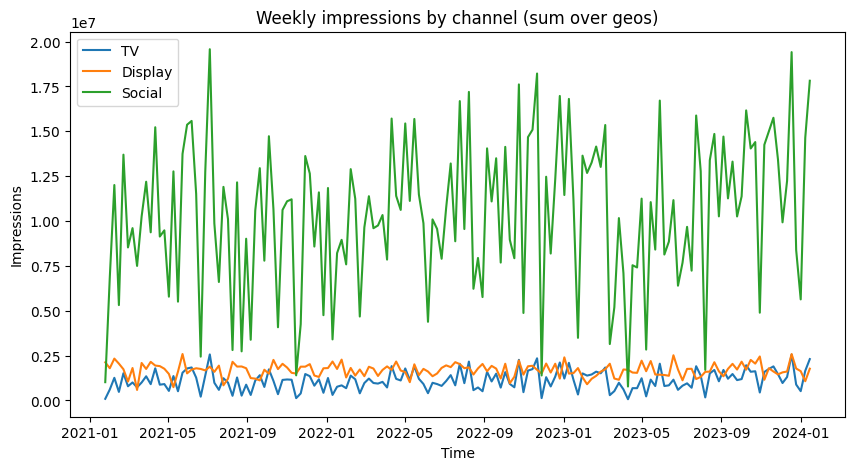

In [2]:
REAL_DATA_CONFIG_OVERRIDES = {
    # Same story/targets as tv-test-under-simple-dgp-coefficient-prior.ipynb.
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {
        'TV': (1, 2),
        'Display': (1, 5),
        'Social': (7.0, 8.0),
    },
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    # Must match the real data's week count -- already the default, kept
    # explicit here since it's load-bearing for this notebook.
    'n_times': 156,
    # Match the DGP's true baseline mu_t flexibility to build_model_spec's
    # fitted knots=8 default below (otherwise mu_t defaults to one
    # independent, unsmoothed shock per week -- a large flexibility
    # mismatch against the fitted spline).
    'n_knots_mu_t': 8,
}

real_df = pd.read_csv(
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_media_rf.csv'
)

config = SimulationConfig.from_dict(REAL_DATA_CONFIG_OVERRIDES)
sim, data, ground_truth = build_real_augmented_input(
    config,
    real_df,
    # TV and Social both reuse the real dataset's only reach/frequency-split
    # channel, independently rescaled to each channel's own target above.
    rf_source_map={'TV': 'Channel3', 'Social': 'Channel3'},
    # Display reuses the real impression-only Channel0 series.
    plain_source_map={'Display': 'Channel0'},
)
sim.plot_media_time_series()
plt.show()

In [3]:
audience_national_m = sim.audience_national_m.numpy()
mean_reach_frac_m = sim.reach_count_gtm.numpy().mean(axis=(0, 1)) / (
    sim.audience_g_m.numpy().mean(axis=0)
)
mean_frequency_m = sim.frequency_gtm.numpy().mean(axis=(0, 1))
true_ec_m = sim.ec_m.numpy()
true_ceiling_frac = ceiling_fraction_at_median(true_ec_m)

for i, ch in enumerate(config.channel_names):
  print(
      f'{ch}: target audience ~ {audience_national_m[i] / 1e6:.1f}M, '
      f'reaching ~ {mean_reach_frac_m[i] * 100:.1f}% at frequency '
      f'~ {mean_frequency_m[i]:.1f}/week'
  )
print()
print(f'true ec_m (multiples of current median delivery): {true_ec_m}')
print(f'true fraction of ceiling effect captured today:   {true_ceiling_frac}')
print(f'true roi_m: {ground_truth["roi_m"]}')

TV: target audience ~ 6.3M, reaching ~ 10.0% at frequency ~ 1.5/week
Display: target audience ~ 1.1M, reaching ~ 50.0% at frequency ~ 3.0/week
Social: target audience ~ 1.6M, reaching ~ 76.7% at frequency ~ 7.5/week

true ec_m (multiples of current median delivery): [11.069365    1.3826793   0.26670453]
true fraction of ceiling effect captured today:   [0.08285441 0.41969556 0.78945005]
true roi_m: [8.000001 5.000001 3.      ]


## 2. Headline diagnostic under `media_prior_type='coefficient'`

Fit `default`, `ec_only`, and `ec_alpha_only` on the real-data-scaled
dataset built in Section 1, with `media_prior_type='coefficient'` -- so
`beta_m` is sampled directly (default prior `HalfNormal(5.0)`) rather than
being deterministically derived from a sampled `roi_m`. `ec_m`/`alpha_m`
prior variants are unchanged from the purely synthetic notebook.

Since `roi_m` is not a native posterior variable under `'coefficient'`, its
summary below is computed post-hoc via `roi_posterior_summary` (wrapping
`analyzer.Analyzer.roi()`) rather than pulled directly from
`az.summary(mmm.inference_data)` the way `alpha_m`/`ec_m` are.

In [4]:
MAIN_VARIANTS = ['default', 'ec_only', 'ec_alpha_only']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)

fitted_mmms = {}
summaries = {}
roi_summaries = {}
for variant in MAIN_VARIANTS:
  model_spec = build_model_spec(
      variant, sim, config, media_prior_type='coefficient'
  )
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS)
  fitted_mmms[variant] = mmm
  summaries[variant] = az.summary(
      mmm.inference_data, extend=True, hdi_prob=0.9
  ).reset_index()
  roi_summaries[variant] = roi_posterior_summary(mmm, config.channel_names)

  print(f'--- {variant} ---')
  display(filter_param_summary(summaries[variant], 'alpha_m'))
  display(filter_param_summary(summaries[variant], 'ec_m'))
  display(roi_summaries[variant])

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


2026-07-27 15:41:59.619676: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


--- default ---


...

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


--- ec_alpha_only ---


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.535,0.019,0.506,0.568,0.000,0.000,2381.0,1296.0,1.0
1,alpha_m[Display],0.099,0.063,0.000,0.185,0.001,0.001,1557.0,650.0,1.0
2,alpha_m[Social],0.273,0.016,0.245,0.299,0.000,0.000,1734.0,1231.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
66,ec_m[TV],11.405,1.164,9.379,13.214,0.022,0.015,2852.0,1494.0,1.0
67,ec_m[Display],1.400,0.141,1.164,1.614,0.002,0.002,3455.0,1373.0,1.0
68,ec_m[Social],0.277,0.024,0.237,0.315,0.000,0.000,2345.0,1629.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,roi_m[TV],7.479,0.418,6.783,8.125,0.009,0.007,1944.0,1768.0,1.0
1,roi_m[Display],5.704,1.124,3.946,7.576,0.031,0.022,1216.0,1408.0,1.0
2,roi_m[Social],3.176,0.149,2.946,3.431,0.003,0.002,1938.0,1512.0,1.0
